In [1]:
# PTB-XL CNN + Transformer Training Notebook

import os
import ast
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc, classification_report, roc_auc_score
from sklearn.preprocessing import MultiLabelBinarizer
from torch.utils.data import Dataset, DataLoader
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import torch
import torch.nn as nn

In [2]:
# Load and Preprocess Data 
from pathlib import Path

dataset_root = Path("/users/PLS0150/shreeshtee/PTBXL-Dataset-Thesiswork/physionet.org/files/ptb-xl/1.0.3")

ptbxl_path = dataset_root / "ptbxl_database.csv"
waveform_path = dataset_root

df = pd.read_csv(ptbxl_path)
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df['scp_keys'] = df['scp_codes'].apply(lambda x: list(x.keys()))
target_labels = ['NORM', 'AFIB', 'PVC', 'LVH', 'IMI', 'ASMI', 'LAFB', 'IRBBB']
df['scp_filtered'] = df['scp_keys'].apply(lambda x: [k for k in x if k in target_labels])
df = df[df['scp_filtered'].map(len) > 0]

mlb = MultiLabelBinarizer(classes=target_labels)
y = mlb.fit_transform(df['scp_filtered'])

mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, test_idx in mskf.split(df, y):
    X_train, X_test = df.iloc[train_idx], df.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    break

afib_index = target_labels.index('AFIB')
afib_mask = y_train[:, afib_index] == 1
X_afib = X_train[afib_mask]
y_afib = y_train[afib_mask]
X_train = pd.concat([X_train] + [X_afib] * 5, ignore_index=True)
y_train = np.vstack([y_train] + [y_afib] * 5)

In [3]:
# Dataset Class
def load_ecg(record_path):
    record = wfdb.rdrecord(record_path)
    return record.p_signal.T

class PTBXL_Dataset(Dataset):
    def __init__(self, df, labels, base_dir):
        self.df = df
        self.labels = labels
        self.base_dir = base_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_path = os.path.join(self.base_dir, row['filename_lr'])
        signal = load_ecg(full_path).T
        return torch.tensor(signal, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.float32)

train_dataset = PTBXL_Dataset(X_train, y_train, waveform_path)
test_dataset = PTBXL_Dataset(X_test, y_test, waveform_path)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=8, num_workers=2, pin_memory=True)

In [4]:
# Model Definition
class ECG_Transformer(nn.Module):
    def __init__(self, seq_len=5000, num_features=12, d_model=32, nhead=2, num_layers=2, num_classes=8):
        super(ECG_Transformer, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=num_features, out_channels=32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=32, out_channels=d_model, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x = self.transformer_encoder(x)
        x = x.permute(0, 2, 1)
        x = self.global_avg_pool(x).squeeze(-1)
        return self.fc(x)

In [5]:
# Training Loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ECG_Transformer().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
y_true, y_pred = [], []

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for signals, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        signals, labels = signals.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = torch.sigmoid(outputs)
        preds[:, afib_index] = (preds[:, afib_index] > 0.3).float()
        for i in range(preds.shape[1]):
            if i != afib_index:
                preds[:, i] = (preds[:, i] > 0.5).float()
        acc = (preds == labels).float().mean().item()
        correct += acc
        total += 1
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}, Accuracy: {correct / total:.4f}")


Epoch 1/10: 100%|██████████| 2546/2546 [01:11<00:00, 35.43it/s]


Epoch 1, Loss: 0.3071, Accuracy: 0.8703


Epoch 2/10: 100%|██████████| 2546/2546 [00:33<00:00, 74.97it/s]


Epoch 2, Loss: 0.2151, Accuracy: 0.9131


Epoch 3/10: 100%|██████████| 2546/2546 [00:35<00:00, 72.36it/s]


...

Epoch 8, Loss: 0.1311, Accuracy: 0.9480


Epoch 9/10: 100%|██████████| 2546/2546 [00:33<00:00, 75.51it/s]


Epoch 9, Loss: 0.1263, Accuracy: 0.9501


Epoch 10/10: 100%|██████████| 2546/2546 [00:33<00:00, 75.59it/s]

Epoch 10, Loss: 0.1212, Accuracy: 0.9517


In [6]:
# Evaluation
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for signals, labels in test_loader:
        signals, labels = signals.to(device), labels.to(device)
        outputs = model(signals)
        y_true.append(labels.cpu().numpy())
        y_pred.append(torch.sigmoid(outputs).cpu().numpy())

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

In [7]:
# Save predictions for ROC comparison
torch.save(model.state_dict(), "transformer_cnn_model.pt")
np.save("y_true_transformer_cnn.npy", y_true)
np.save("y_pred_transformer_cnn.npy", y_pred)

In [8]:
# Apply threshold for AFIB and generate report
thresholds = np.full(y_pred.shape[1], 0.5)
thresholds[1] = 0.3
preds = (y_pred > thresholds).astype(int)

print("Classification Report:")
print(classification_report(y_true, preds, target_names=mlb.classes_))
print("Macro ROC-AUC:", roc_auc_score(y_true, y_pred, average='macro'))

Classification Report:
              precision    recall  f1-score   support

        NORM       0.88      0.93      0.91      1903
        AFIB       0.63      0.89      0.74       303
         PVC       0.79      0.76      0.78       229
         LVH       0.82      0.58      0.68       427
         IMI       0.73      0.72      0.73       535
        ASMI       0.74      0.81      0.77       472
        LAFB       0.71      0.90      0.79       325
       IRBBB       0.64      0.65      0.65       224

   micro avg       0.79      0.83      0.81      4418
   macro avg       0.74      0.78      0.76      4418
weighted avg       0.80      0.83      0.81      4418
 samples avg       0.83      0.86      0.83      4418

Macro ROC-AUC: 0.9643205222561744


/users/PLS0150/shreeshtee/Hybrid-CNN-Transformer-ECG/.venv/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


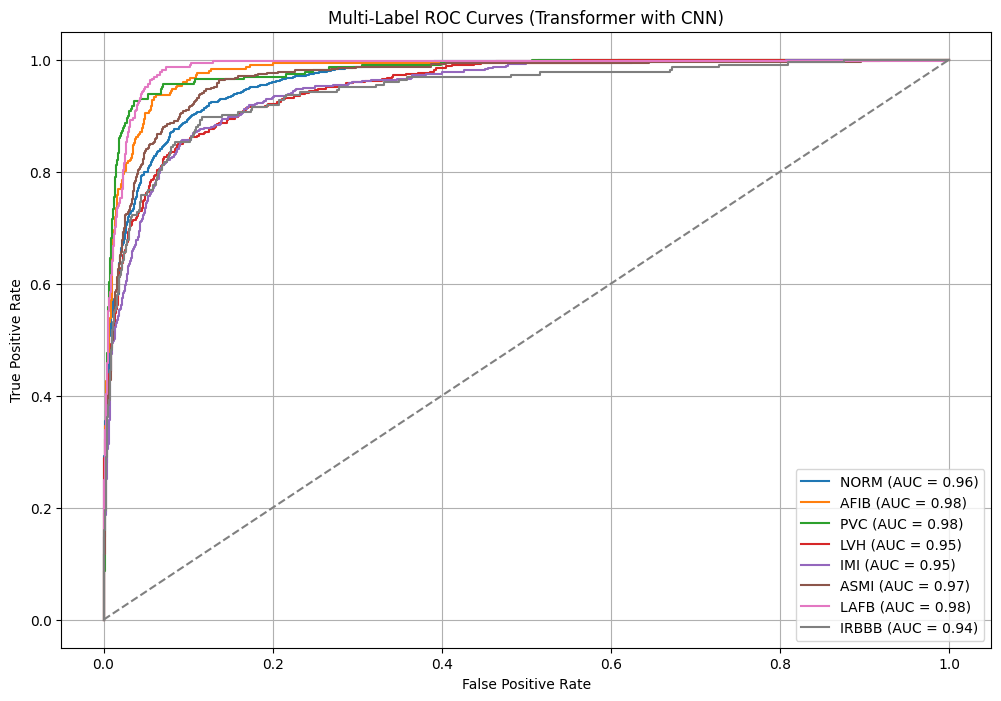

In [9]:
# Plot ROC Curves
plt.figure(figsize=(12, 8))
for i, label in enumerate(mlb.classes_):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Label ROC Curves (Transformer with CNN)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

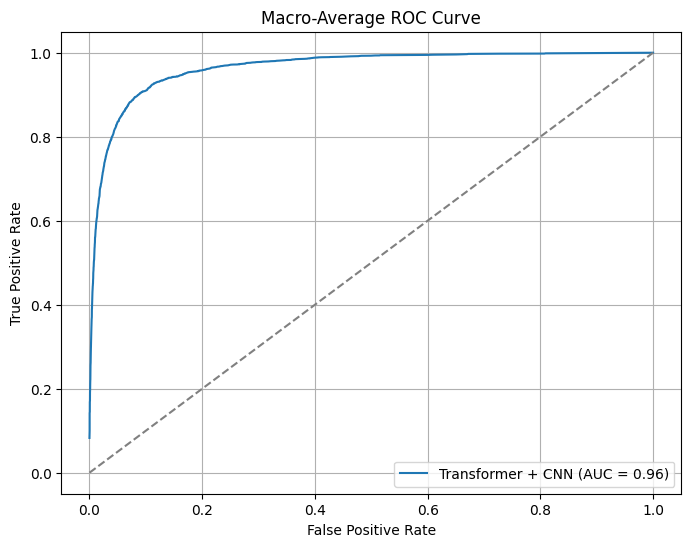

In [10]:
# Macro-Average ROC
def compute_macro_roc(y_true, y_pred):
    n_classes = y_true.shape[1]
    fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])
    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    return all_fpr, mean_tpr, macro_auc

fpr, tpr, macro_auc = compute_macro_roc(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Transformer + CNN (AUC = {macro_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Macro-Average ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [11]:
np.save("y_true_transformer_CNN.npy", y_true)
np.save("y_pred_transformer_CNN.npy", y_pred)